# Forest Mask CLI Test

`services/forest_mask/cli.py` の `main` をプロジェクトルートから実行する想定でテストする。

- 入力: `data/input/jpg/sample/sample_tree.jpg`
- 出力:
  - `data/intermediate/exg/exg_<timestamp>.jpg`
  - `data/intermediate/forest_mask/fmask_<timestamp>.jpg`
  - `data/intermediate/forest_mask/fmask_morph_cl_cl_<timestamp>.jpg` (closing)
  - `data/intermediate/forest_mask/fmask_morph_op_cl_<timestamp>.jpg` (opening)

In [5]:
# プロジェクトルートで実行できるようにカレントを移動
import os
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
    os.chdir(PROJECT_ROOT)

print("cwd:", Path.cwd())

cwd: /home/mqsol/works/forest-analyzer


In [6]:
# モジュールリロードを有効化（実装変更を即反映するため）
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
from click.testing import CliRunner

from services.forest_mask.cli import main

INPUT_PATH = "data/input/jpg/sample/sample_tree.jpg"
THRESHOLD = 10.0

runner = CliRunner()
result = runner.invoke(
    main,
    [INPUT_PATH, "--threshold", str(THRESHOLD)],
    catch_exceptions=False,
)

print(result.output)
assert result.exit_code == 0, f"exit_code={result.exit_code}"

Saved: data/intermediate/exg/exg_20260520145600.jpg
Saved: data/intermediate/forest_mask/fmask_20260520145600.jpg
Saved: data/intermediate/forest_mask/fmask_morph_cl_cl_20260520145600.jpg
Saved: data/intermediate/forest_mask/fmask_morph_op_cl_20260520145600.jpg



latest exg  : data/intermediate/exg/exg_20260520145600.jpg
latest mask : data/intermediate/forest_mask/fmask_20260520145600.jpg
latest close: data/intermediate/forest_mask/fmask_morph_cl_cl_20260520145600.jpg
latest open : data/intermediate/forest_mask/fmask_morph_op_cl_20260520145600.jpg


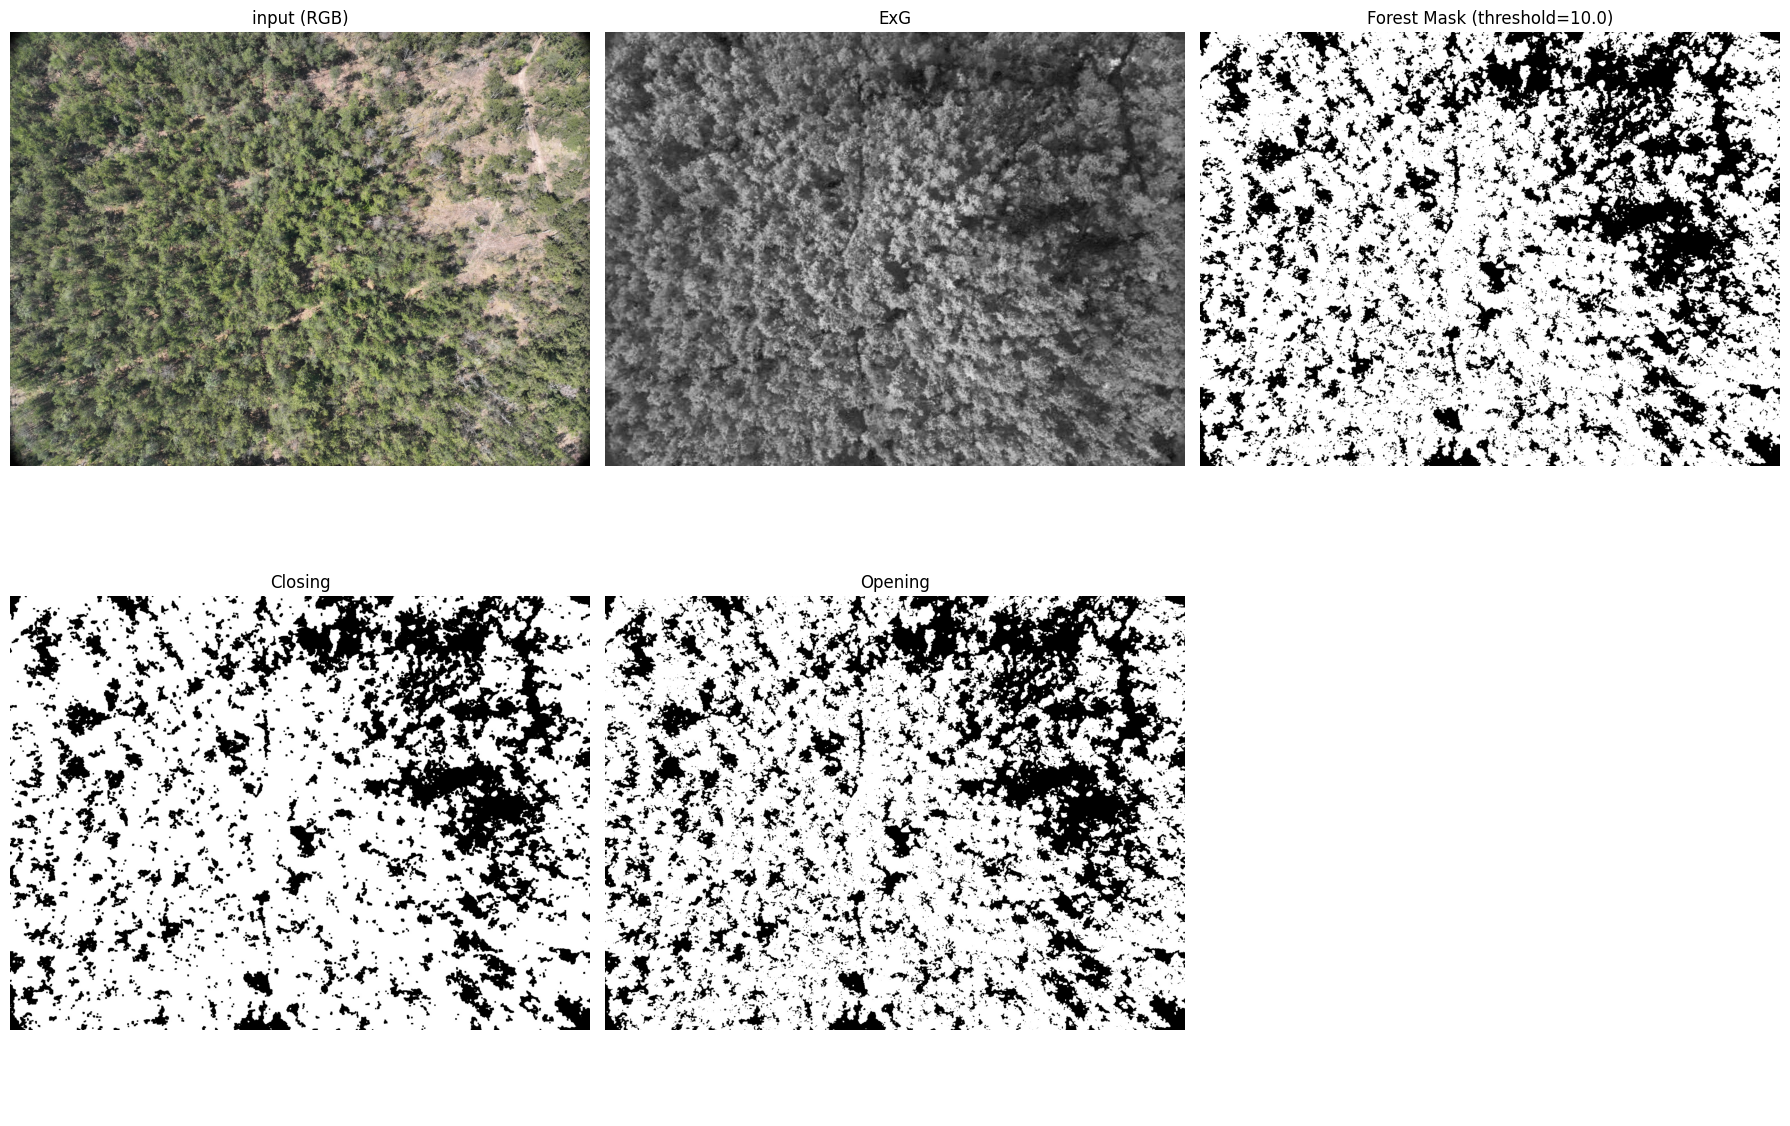

In [8]:
# 出力結果の確認: 入力・ExG・Forest Mask・Closing・Opening をテーブル表示
import cv2
import matplotlib.pyplot as plt

from services.common.image import load_rgb

exg_dir = Path("data/intermediate/exg")
mask_dir = Path("data/intermediate/forest_mask")

latest_exg = max(exg_dir.glob("exg_*.jpg"), key=lambda p: p.stat().st_mtime)
latest_mask = max(
    (p for p in mask_dir.glob("fmask_*.jpg") if not p.name.startswith("fmask_morph_")),
    key=lambda p: p.stat().st_mtime,
)
latest_close = max(mask_dir.glob("fmask_morph_cl_*.jpg"), key=lambda p: p.stat().st_mtime)
latest_open = max(mask_dir.glob("fmask_morph_op_*.jpg"), key=lambda p: p.stat().st_mtime)
print("latest exg  :", latest_exg)
print("latest mask :", latest_mask)
print("latest close:", latest_close)
print("latest open :", latest_open)

rgb = load_rgb(Path(INPUT_PATH))
exg = cv2.imread(str(latest_exg), cv2.IMREAD_GRAYSCALE)
mask = cv2.imread(str(latest_mask), cv2.IMREAD_GRAYSCALE)
close_mask = cv2.imread(str(latest_close), cv2.IMREAD_GRAYSCALE)
open_mask = cv2.imread(str(latest_open), cv2.IMREAD_GRAYSCALE)

# テーブル状レイアウト (空きセルは詰める)
# 後で画像が増えたら panels に追加する
panels = [
    ("input (RGB)", rgb, None),
    ("ExG", exg, "gray"),
    (f"Forest Mask (threshold={THRESHOLD})", mask, "gray"),
    ("Closing", close_mask, "gray"),
    ("Opening", open_mask, "gray"),
]

n_cols = 3
n_rows = (len(panels) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 6 * n_rows))
axes = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else list(axes)

for ax, (title, img, cmap) in zip(axes, panels):
    ax.imshow(img, cmap=cmap)
    ax.set_title(title)
    ax.axis("off")

for ax in axes[len(panels):]:
    ax.axis("off")

plt.tight_layout()
plt.show()